In [17]:
import cv2
import os
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import transforms
screen_width = 1920
screen_height = 1080
width=400
height=500
height_add=100
game_region = {
    'width': width,
    'height': height,
    'left': (screen_width - width) // 2,
    'top': (screen_height + height_add - height) // 2
}
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import time



In [ ]:


DATASET_DIR = os.path.join("dataset")
DATASET_PATHS = {
    "jump": os.path.join(DATASET_DIR, "jump"),
    "roll": os.path.join(DATASET_DIR, "roll"),
    "left": os.path.join(DATASET_DIR, "left"),
    "right": os.path.join(DATASET_DIR, "right"),
    "noop": os.path.join(DATASET_DIR, "noop")
}
ACTIONS= {
    
    "jump": 1,
    "roll": 2,
    "left": 3,
    "right": 4,
    "noop": 5,
    "jump_reversed": 1,
    "roll_reversed": 2,
    "left_reversed": 4,
    "right_reversed": 3,  # Reversed actions for left and right
    "noop_reversed": 5
}



In [3]:

class CropRegionTransformGameRegion:
    def __call__(self, img):
        left = game_region["left"]
        top = game_region["top"]
        right = left + game_region["width"]
        bottom = top + game_region["height"]

        return img.crop((left, top, right, bottom))
    


In [6]:
transform = transforms.Compose([
    CropRegionTransformGameRegion(),
    transforms.Grayscale(),
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../dataset",
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)



In [15]:
t=time.time()
path = "../dataset/jump"
img_name =  os.listdir(path)[10]
  
img = Image.open(os.path.join(path, img_name))
transformed = transform(img)
print(f"Time taken for transformation: {time.time() - t:.4f} seconds")
cv2.imshow("Transformed Image", transformed.permute(1, 2, 0).numpy())
cv2.waitKey(0)

cv2.destroyAllWindows()


Time taken for transformation: 0.0415 seconds


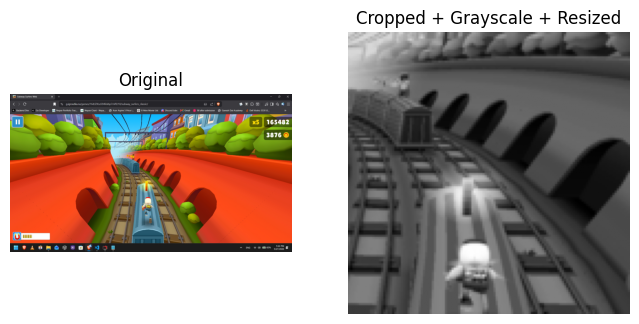

In [ ]:

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Cropped + Grayscale + Resized")
plt.imshow(transformed.squeeze(), cmap="gray")

plt.axis("off")

plt.show()

In [24]:
import torch

device = torch.device("xpu")

x = torch.randn(3, 3).to(device)
y = x @ x

print(y)
print(y.device)

AssertionError: Torch not compiled with XPU enabled

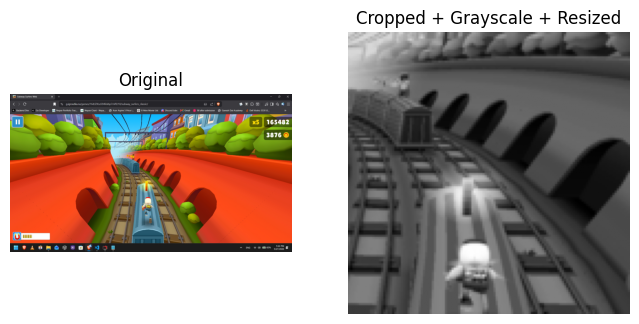

In [ ]:

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Cropped + Grayscale + Resized")
plt.imshow(transformed.squeeze(), cmap="gray")

plt.axis("off")

plt.show()